# 08_Spatial_Umap
## Xiaonan Wang
## 18Sep2026

In [1]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [2]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


In [3]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read In Files

In [4]:
x_all = sc.read_h5ad(datadir + "all_updated.h5ad")

In [5]:
AT2 = sc.read_h5ad(outdir + "AT2_updated.h5ad")

In [6]:
x_all, report_AT2 = source.merge_obs_to_main(
    main_adata=x_all,
    subset_adata=AT2,
    columns={
        "AT2_VIMhi_score": "AT2_VIMhi_score",
        "AT2_VIMlo_score": "AT2_VIMlo_score",
        "AT2_VIM_score": "AT2_VIM_score",
        "AT2_VIM_group": "AT2_VIM_group",
    },
    overwrite=True,
    strict_subset=True,
    source_name="AM",
)

In [7]:
stage2_results_dict = pd.read_pickle(
    "Stage2_all_results.pkl.gz",
    compression="gzip",
)
radius_results_all = stage2_results_dict["radius_continuum"]

In [18]:
radius_results_all.columns

Index(['method', 'direction', 'scale_type', 'scale', 'effect_type', 'core_id',
       'donor_id', 'tissue_annotation', 'n_cells', 'n_am', 'n_at2',
       'n_am_analyzed', 'n_am_without_neighbors', 'observed', 'null_mean',
       'null_sd', 'zscore', 'effect', 'p_association', 'p_two_sided',
       'rho_score_at2_fraction', 'mean_at2_fraction', 'pct_am_with_at2',
       'mean_at2_neighbors', 'mean_total_neighbors',
       'pct_am_without_neighbors', 'FDR_core'],
      dtype='object')

In [8]:
for column in [
    "method",
    "direction",
    "scale_type",
    "effect_type",
]:
    print(
        f"\n{column}:",
        radius_results_all[
            column
        ].dropna().unique()
    )


method: ['Continuous MHCII radius']

direction: ['MHCII score → AT2 exposure']

scale_type: ['radius_um']

effect_type: ['correlation']


In [9]:
display(
    radius_results_all.loc[
        np.isclose(
            pd.to_numeric(
                radius_results_all["scale"],
                errors="coerce",
            ),
            50,
        )
    ]
    .groupby(
        [
            "method",
            "direction",
            "scale_type",
            "effect_type",
        ],
        dropna=False,
    )
    .size()
    .rename("n_rows")
    .reset_index()
)

,method,direction,scale_type,effect_type,n_rows
0,Continuous MHCII radius,MHCII score → AT2 exposure,radius_um,correlation,68


In [11]:
import inspect
source_text = inspect.getsource(
    source.rank_stage2_core_contributions
)

print(
    "n_am_analyzed"
    in source_text
)

True


In [12]:
stage2_radius_core = (
    radius_results_all.loc[
        radius_results_all[
            "rho_score_at2_fraction"
        ].notna()
    ]
    .copy()
)

In [13]:
print(
    "n_am_analyzed"
    in stage2_radius_core.columns
)

print(
    stage2_radius_core[
        "n_am_analyzed"
    ].describe()
)

True
count     204
unique    126
top        28
freq        5
Name: n_am_analyzed, dtype: int64


## Step1 - Rank Contributions for Each Core For A Only

In [14]:
core_ranking_A50, donor_ranking_A50, summary_A50 = (
    source.rank_stage2_core_contributions(
        core_results=stage2_radius_core,
        tissue="A",
        radius=50,
        core_col="core_id",
        donor_col="donor_id",
        tissue_col="tissue_annotation",
        radius_col="scale",
        effect_col=(
            "rho_score_at2_fraction"
        ),
        n_col="n_am_analyzed",
        min_donors_for_test=3,
    )
)

In [15]:
print(
    core_ranking_A50.columns.tolist()
)

assert (
    "n_am_analyzed"
    in core_ranking_A50.columns
), (
    "n_am_analyzed was not retained "
    "in the reconstructed ranking."
)

['influence_rank', 'core_id', 'donor_id', 'tissue_annotation', 'radius_um', 'method', 'direction', 'scale_type', 'core_rho', 'core_weight', 'removes_donor', 'loo_n_donors', 'loo_mean_donor_rho', 'loo_median_donor_rho', 'loo_wilcoxon_p', 'influence_on_mean_donor_rho', 'influence_on_median_donor_rho', 'distance_to_tissue_median', 'conclusion', 'n_am_analyzed']


In [16]:
display(
    core_ranking_A50[
        [
            "influence_rank",
            "core_id",
            "donor_id",
            "n_am_analyzed",
            "core_rho",
            "influence_on_mean_donor_rho",
            "influence_on_median_donor_rho",
            "loo_wilcoxon_p",
            "conclusion",
        ]
    ]
)

,influence_rank,core_id,donor_id,n_am_analyzed,core_rho,influence_on_mean_donor_rho,influence_on_median_donor_rho,loo_wilcoxon_p,conclusion
0,1,D19.c2,D19,19,0.221146,0.008026,0.005586,0.029754,Supports positive association
1,2,D13.c1,D13,269,0.167191,0.005802,0.002793,0.014788,Supports positive association
2,3,D7.c3,D7,128,0.307638,0.004571,0.000000,0.008773,Supports positive association
3,4,D17.c4,D17,25,0.031997,0.004198,0.000000,0.014507,Supports positive association
4,5,D18.c2,D18,28,0.130391,0.003998,0.000000,0.014507,Supports positive association
5,6,D15.c3,D15,177,0.119380,0.003412,0.002793,0.013321,Supports positive association
6,7,D21.c2,D21,446,0.335192,0.003190,0.000000,0.008773,Supports positive association
7,8,D3.c1,D3,123,0.099051,0.002395,0.002793,0.013321,Supports positive association
8,9,D2.c3,D2,248,0.067246,0.002264,0.000000,0.010786,Supports positive association
9,10,D10.c2,D10,815,0.042503,0.002242,0.000000,0.010786,Supports positive association


In [17]:
core_metadata_A50 = (
    radius_results_all.loc[
        radius_results_all[
            "tissue_annotation"
        ].astype(str).eq("A")
        & np.isclose(
            pd.to_numeric(
                radius_results_all[
                    "scale"
                ],
                errors="coerce",
            ),
            50,
        )
        & radius_results_all[
            "rho_score_at2_fraction"
        ].notna(),
        [
            "core_id",
            "n_cells",
            "n_am",
            "n_at2",
            "n_am_analyzed",
            "n_am_without_neighbors",
            "pct_am_with_at2",
            "mean_at2_fraction",
            "mean_at2_neighbors",
            "mean_total_neighbors",
            "pct_am_without_neighbors",
            "FDR_core",
        ],
    ]
    .groupby(
        "core_id",
        as_index=False,
        observed=True,
    )
    .first()
)

In [18]:
metadata_columns = [
    column
    for column in core_metadata_A50.columns
    if column != "core_id"
]

columns_to_remove = []

for column in metadata_columns:

    columns_to_remove.extend([
        column,
        f"{column}_x",
        f"{column}_y",
        f"{column}_radius",
    ])

columns_to_remove = [
    column
    for column in columns_to_remove
    if column in core_ranking_A50.columns
]

In [19]:
core_ranking_A50 = (
    core_ranking_A50
    .drop(
        columns=columns_to_remove,
        errors="ignore",
    )
    .merge(
        core_metadata_A50,
        on="core_id",
        how="left",
        validate="one_to_one",
    )
)

In [20]:
assert (
    "n_am_analyzed"
    in core_ranking_A50.columns
)

print(
    core_ranking_A50[
        "n_am_analyzed"
    ].isna().sum(),
    "cores have missing n_am_analyzed"
)

0 cores have missing n_am_analyzed


In [21]:
display(
    core_ranking_A50[
        [
            "influence_rank",
            "core_id",
            "donor_id",
            "n_am_analyzed",
            "n_at2",
            "pct_am_with_at2",
            "core_rho",
            "influence_on_mean_donor_rho",
            "FDR_core",
            "conclusion",
        ]
    ]
)

,influence_rank,core_id,donor_id,n_am_analyzed,n_at2,pct_am_with_at2,core_rho,influence_on_mean_donor_rho,FDR_core,conclusion
0,1,D19.c2,D19,19,26,31.578947,0.221146,0.008026,0.533538,Supports positive association
1,2,D13.c1,D13,269,159,49.442379,0.167191,0.005802,0.027200,Supports positive association
2,3,D7.c3,D7,128,428,64.062500,0.307638,0.004571,0.027200,Supports positive association
3,4,D17.c4,D17,25,967,96.000000,0.031997,0.004198,0.720182,Supports positive association
4,5,D18.c2,D18,28,24,17.857143,0.130391,0.003998,0.550000,Supports positive association
5,6,D15.c3,D15,177,412,77.401130,0.119380,0.003412,0.282462,Supports positive association
6,7,D21.c2,D21,446,321,23.542601,0.335192,0.003190,0.027200,Supports positive association
7,8,D3.c1,D3,123,33,22.764228,0.099051,0.002395,0.431800,Supports positive association
8,9,D2.c3,D2,248,449,83.064516,0.067246,0.002264,0.472762,Supports positive association
9,10,D10.c2,D10,815,807,65.398773,0.042503,0.002242,0.380000,Supports positive association


In [22]:
selected_cores_A50 = (
    source.select_supportive_cores(
        core_ranking_A50,
        n_supportive=5,
        include_typical=True,
        include_discordant=True,
    )
)

display(
    selected_cores_A50[
        [
            "core_id",
            "donor_id",
            "core_rho",
            "influence_on_mean_donor_rho",
            "n_am_analyzed",
            "pct_am_with_at2",
            "selection_reason",
        ]
    ]
)

,core_id,donor_id,core_rho,influence_on_mean_donor_rho,n_am_analyzed,pct_am_with_at2,selection_reason
0,D19.c2,D19,0.221146,0.008026,19,31.578947,Strong supportive core
1,D13.c1,D13,0.167191,0.005802,269,49.442379,Strong supportive core
2,D7.c3,D7,0.307638,0.004571,128,64.062500,Strong supportive core
3,D17.c4,D17,0.031997,0.004198,25,96.000000,Strong supportive core
4,D18.c2,D18,0.130391,0.003998,28,17.857143,Strong supportive core
5,D21.c3,D21,0.056253,-0.003451,110,70.000000,Typical positive core
6,D12.c4,D12,-0.174332,-0.002989,186,59.139785,Discordant negative core


## Step2 - Plotting

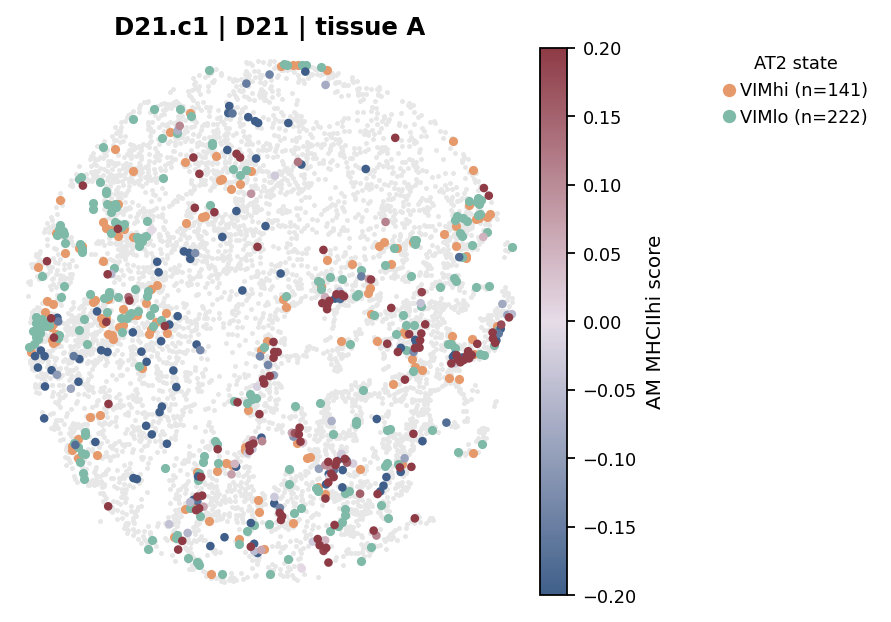

In [23]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D21.c1",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

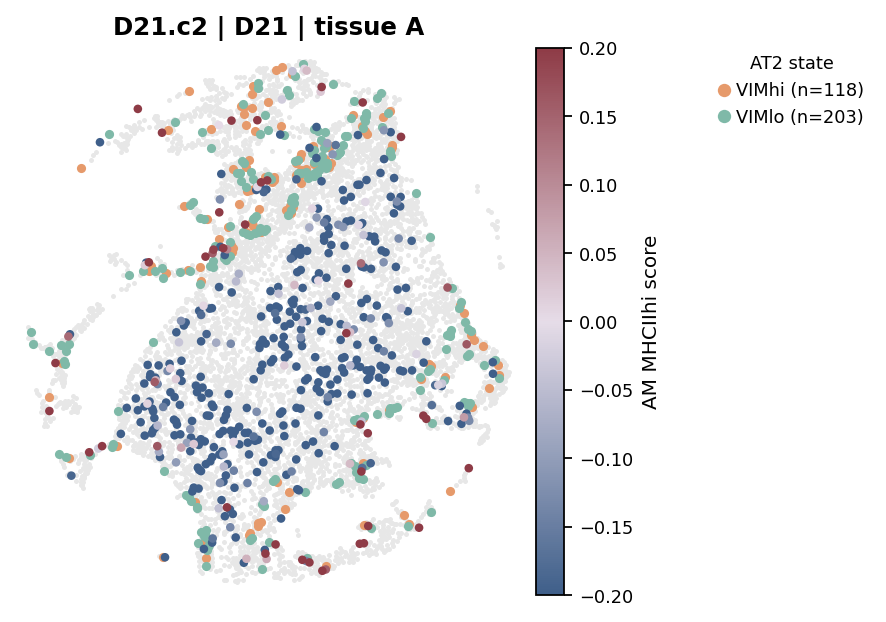

In [24]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D21.c2",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

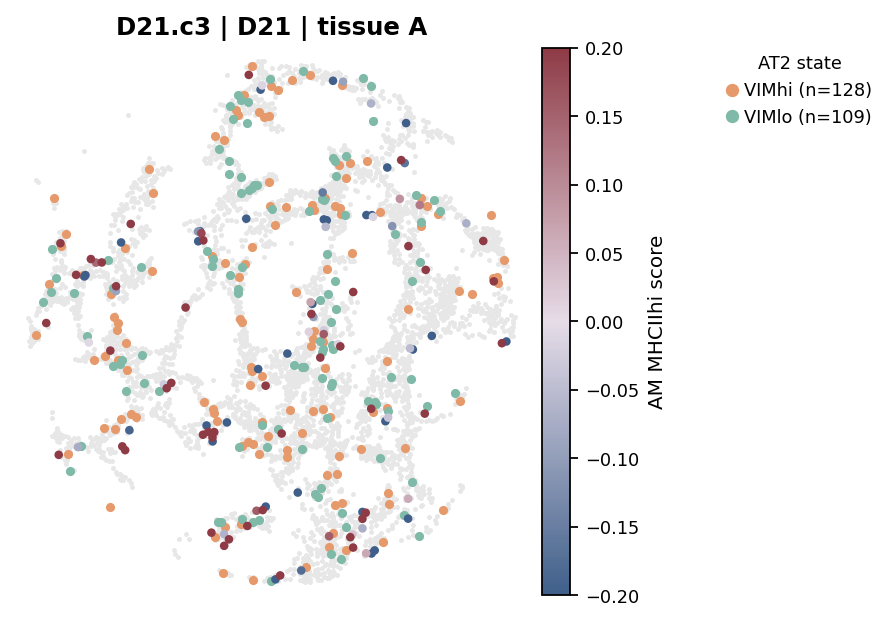

In [25]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D21.c3",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

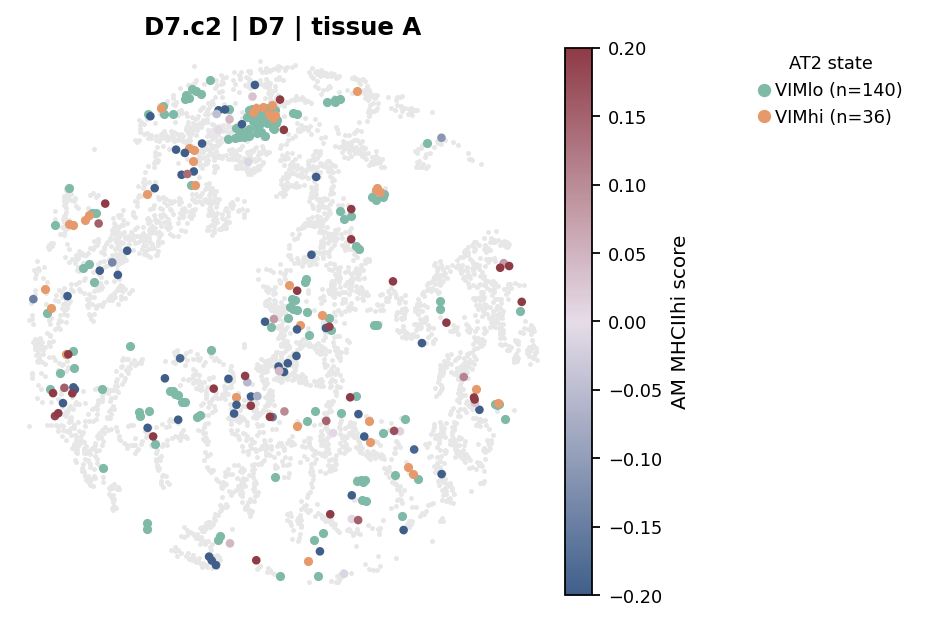

In [26]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D7.c2",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

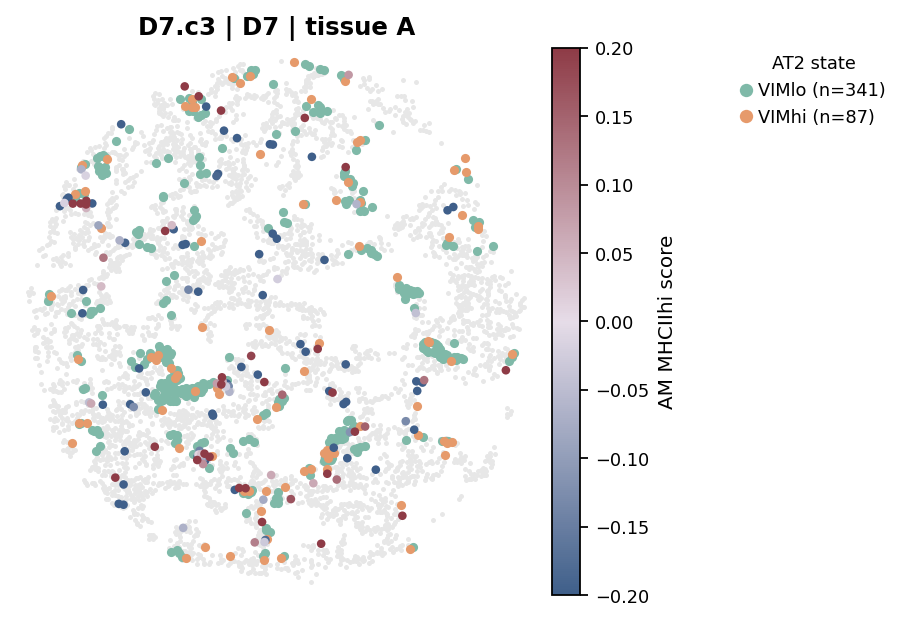

In [27]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D7.c3",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

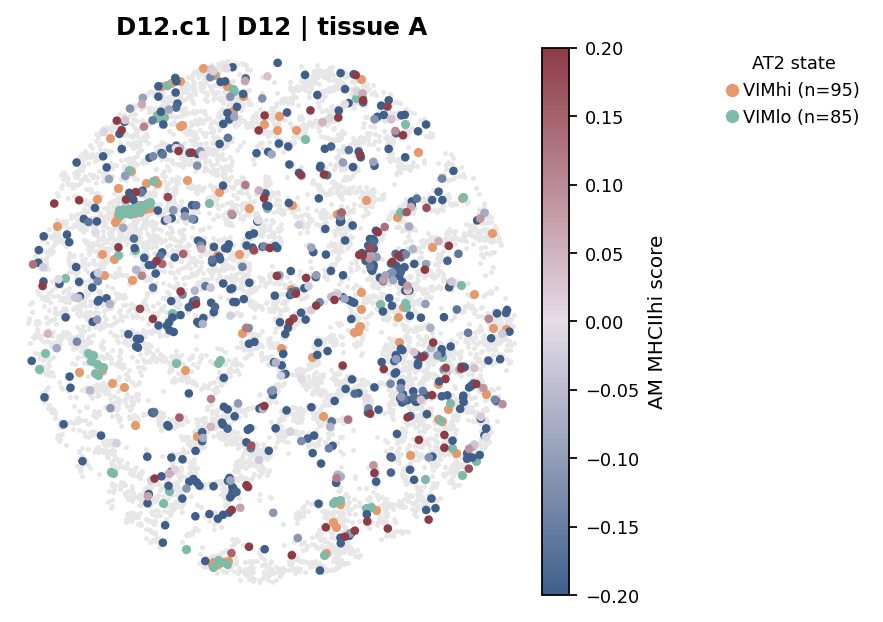

In [28]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D12.c1",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

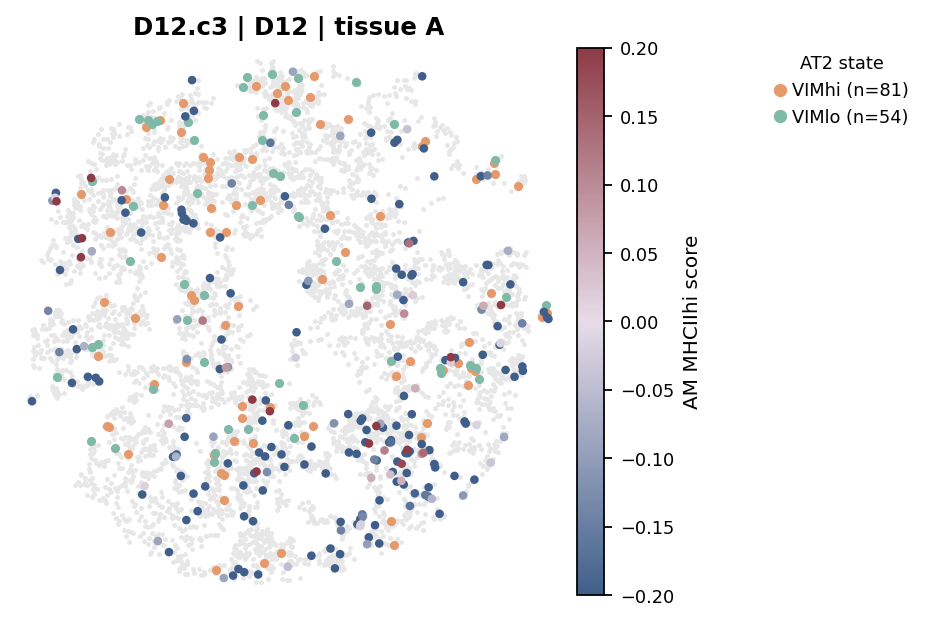

In [30]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D12.c3",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

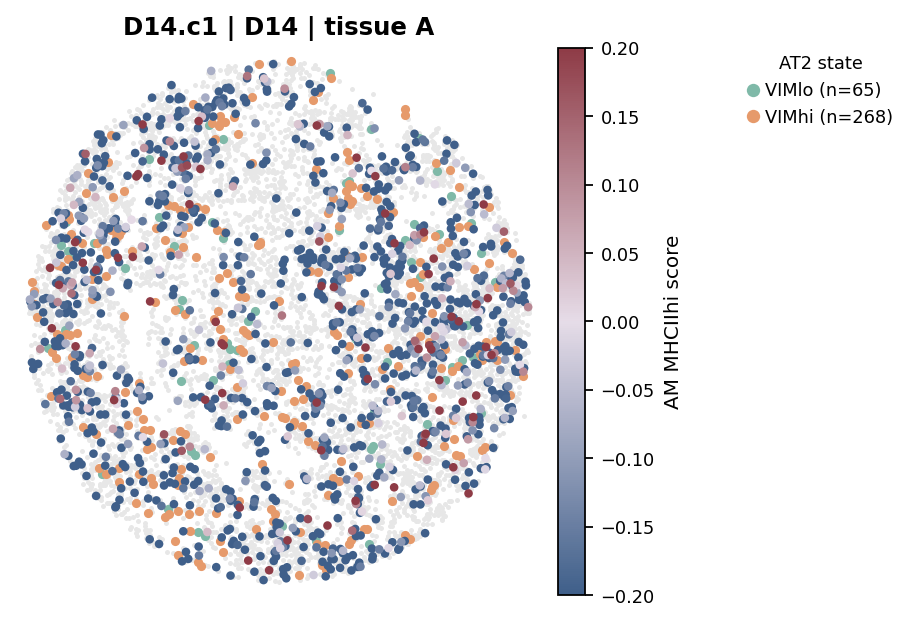

In [38]:
output_file = source.plot_mhcii_at2_spatial_core(
    adata=x_all,
    core_id="D14.c1",

    at2_display="group",
    at2_group_col="AT2_VIM_group",

    at2_group_order=(
        "AT2_VIMhi",
        "AT2_VIMlo",
        # "Ambiguous",
    ),

    at2_group_colors={
        "VIMhi": "#E69A6B",
        "VIMlo": "#7FB9A8",
        # "Ambiguous": "#BFC3C7",
        "Unassigned": "#D9D9D9",
    },

    show_at2_counts=True,
    legend_outside=True,
    low_score_color="#3F5F8A",
    midpoint_color="#E6DCE8",
    high_score_color="#8E3B46",

    score_limits=(-0.2,0.2),
    point_size=15,
    background_size=5,
    show=True,
    dpi=300,

    output_dir="Stage3_spatial_plots",
    file_prefix="MHCII_AT2_VIM_group",
)

In [51]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy import sparse


def plot_gene_spatial_core(
    adata,
    core_id,
    gene,
    output_dir=None,
    file_prefix="Spatial_gene",
    core_col="core_id",
    donor_col="donor_id",
    tissue_col="tissue_annotation",
    spatial_key="spatial",
    layer=None,
    use_raw=False,
    point_size=7,
    background_size=None,
    background_color="#E8E8E8",
    low_color="#F4E9E5",
    middle_color="#E9A6AD",
    high_color="#6F78B8",
    expression_quantiles=(0.01, 0.99),
    expression_limits=None,
    zero_as_background=True,
    invert_y=True,
    width_cm=11,
    height_cm=9,
    rasterized=True,
    show=True,
    dpi=300,
):
    """
    Plot expression of one gene on the spatial coordinates of one core.

    Parameters
    ----------
    adata
        AnnData object.
    core_id
        Core identifier, for example "D21.c2".
    gene
        Gene name.
    output_dir
        If provided, save the plot as a PDF.
    layer
        AnnData layer containing expression. Use None for adata.X.
    use_raw
        Read expression from adata.raw.X. Cannot be combined with layer.
    zero_as_background
        Plot zero-expression cells in grey and positive-expression
        cells with the expression colormap.
    expression_quantiles
        Quantiles used for vmin and vmax, calculated within this core.
    expression_limits
        Explicit (vmin, vmax); overrides expression_quantiles.

    Returns
    -------
    dict
        Figure, axis, core-level plotting data and saved path.
    """
    if core_col not in adata.obs.columns:
        raise KeyError(f"{core_col!r} is missing from adata.obs.")

    if spatial_key not in adata.obsm:
        raise KeyError(f"adata.obsm[{spatial_key!r}] is missing.")

    if layer is not None and use_raw:
        raise ValueError("Specify either layer or use_raw=True, not both.")

    # ------------------------------------------------------------
    # Extract gene expression
    # ------------------------------------------------------------
    if use_raw:
        if adata.raw is None:
            raise ValueError("adata.raw is not available.")

        if gene not in adata.raw.var_names:
            raise KeyError(f"{gene!r} is not present in adata.raw.var_names.")

        expression = adata.raw[:, [gene]].X

    elif layer is not None:
        if layer not in adata.layers:
            raise KeyError(f"Layer {layer!r} is not present in adata.layers.")

        if gene not in adata.var_names:
            raise KeyError(f"{gene!r} is not present in adata.var_names.")

        expression = adata[:, [gene]].layers[layer]

    else:
        if gene not in adata.var_names:
            raise KeyError(f"{gene!r} is not present in adata.var_names.")

        expression = adata[:, [gene]].X

    if sparse.issparse(expression):
        expression = expression.toarray()

    expression = np.asarray(expression).reshape(-1).astype(float)

    # ------------------------------------------------------------
    # Extract spatial coordinates
    # ------------------------------------------------------------
    coordinates = np.asarray(adata.obsm[spatial_key], dtype=float)

    if (
        coordinates.ndim != 2
        or coordinates.shape[0] != adata.n_obs
        or coordinates.shape[1] < 2
    ):
        raise ValueError(
            "Spatial coordinates must have one row per cell and "
            "at least two columns."
        )

    coordinates = coordinates[:, :2]

    core_id_string = str(core_id)
    core_mask = (
        adata.obs[core_col]
        .astype(str)
        .eq(core_id_string)
        .to_numpy()
    )

    if not core_mask.any():
        available = (
            adata.obs[core_col]
            .astype(str)
            .drop_duplicates()
            .tolist()[:10]
        )
        raise ValueError(
            f"Core {core_id_string!r} was not found. "
            f"First available cores: {available}"
        )

    core_obs = adata.obs.loc[core_mask].copy()
    core_xy = coordinates[core_mask]
    core_expression = expression[core_mask]

    finite = (
        np.isfinite(core_xy[:, 0])
        & np.isfinite(core_xy[:, 1])
        & np.isfinite(core_expression)
    )

    core_obs = core_obs.loc[finite].copy()
    core_xy = core_xy[finite]
    core_expression = core_expression[finite]

    if len(core_expression) == 0:
        raise ValueError(
            f"No cells with finite coordinates and expression "
            f"were found in core {core_id_string!r}."
        )

    # ------------------------------------------------------------
    # Set expression limits
    # ------------------------------------------------------------
    if expression_limits is not None:
        if len(expression_limits) != 2:
            raise ValueError(
                "expression_limits must contain (vmin, vmax)."
            )

        vmin, vmax = map(float, expression_limits)

    else:
        q_low, q_high = expression_quantiles

        if not 0 <= q_low < q_high <= 1:
            raise ValueError(
                "expression_quantiles must satisfy "
                "0 <= low < high <= 1."
            )

        values_for_scale = core_expression

        # If zeros are background, use detected cells to determine
        # the color scale when possible.
        if zero_as_background:
            detected = core_expression > 0

            if detected.any():
                values_for_scale = core_expression[detected]

        vmin, vmax = np.quantile(
            values_for_scale,
            [q_low, q_high],
        )

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        raise ValueError("Expression limits must be finite.")

    if vmax <= vmin:
        vmax = vmin + 1e-9

    cmap = LinearSegmentedColormap.from_list(
        "macaron_gene_expression",
        [low_color, middle_color, high_color],
        N=256,
    )
    norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

    # ------------------------------------------------------------
    # Prepare plotting order
    # ------------------------------------------------------------
    if zero_as_background:
        colored = core_expression > 0
    else:
        colored = np.ones(len(core_expression), dtype=bool)

    # Draw high-expression cells last so that they remain visible.
    colored_order = np.argsort(core_expression[colored])

    background_size = (
        max(point_size * 0.65, 1)
        if background_size is None
        else background_size
    )

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    cm_to_inch = 1 / 2.54

    fig, ax = plt.subplots(
        figsize=(
            width_cm * cm_to_inch,
            height_cm * cm_to_inch,
        )
    )

    if zero_as_background:
        ax.scatter(
            core_xy[~colored, 0],
            core_xy[~colored, 1],
            s=background_size,
            color=background_color,
            linewidths=0,
            rasterized=rasterized,
            zorder=1,
        )

    scatter = ax.scatter(
        core_xy[colored][colored_order, 0],
        core_xy[colored][colored_order, 1],
        c=core_expression[colored][colored_order],
        s=point_size,
        cmap=cmap,
        norm=norm,
        linewidths=0,
        rasterized=rasterized,
        zorder=2,
    )

    # ------------------------------------------------------------
    # Title
    # ------------------------------------------------------------
    title_parts = [core_id_string]

    if donor_col in core_obs.columns:
        donors = core_obs[donor_col].dropna().astype(str).unique()
        if len(donors):
            title_parts.append(f"donor {donors[0]}")

    if tissue_col in core_obs.columns:
        tissues = (
            core_obs[tissue_col]
            .dropna()
            .astype(str)
            .unique()
        )
        if len(tissues):
            title_parts.append(f"tissue {tissues[0]}")

    ax.set_title(
        f"{gene} expression\n" + " | ".join(title_parts),
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    # ------------------------------------------------------------
    # Spatial formatting
    # ------------------------------------------------------------
    x_min, x_max = core_xy[:, 0].min(), core_xy[:, 0].max()
    y_min, y_max = core_xy[:, 1].min(), core_xy[:, 1].max()

    x_padding = max((x_max - x_min) * 0.025, 1)
    y_padding = max((y_max - y_min) * 0.025, 1)

    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)

    if invert_y:
        ax.invert_yaxis()

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    colorbar = fig.colorbar(
        scatter,
        ax=ax,
        fraction=0.046,
        pad=0.025,
    )
    colorbar.set_label(
        f"{gene} expression",
        fontsize=9,
    )
    colorbar.ax.tick_params(
        labelsize=8,
        width=0.7,
        length=2.5,
    )
    colorbar.outline.set_linewidth(0.7)

    fig.tight_layout()

    # ------------------------------------------------------------
    # Save
    # ------------------------------------------------------------
    saved_path = None

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        safe_core = re.sub(
            r"[^A-Za-z0-9_.-]+",
            "_",
            core_id_string,
        )
        safe_gene = re.sub(
            r"[^A-Za-z0-9_.-]+",
            "_",
            str(gene),
        )

        saved_path = (
            output_dir
            / f"{file_prefix}_{safe_core}_{safe_gene}.pdf"
        )

        fig.savefig(
            saved_path,
            dpi=dpi,
            bbox_inches="tight",
        )

    if show:
        plt.show()

    return {
        "fig": fig,
        "ax": ax,
        "plot_data": pd.DataFrame(
            {
                "x": core_xy[:, 0],
                "y": core_xy[:, 1],
                "expression": core_expression,
            },
            index=core_obs.index,
        ),
        "vmin": vmin,
        "vmax": vmax,
        "output_file": saved_path,
    }

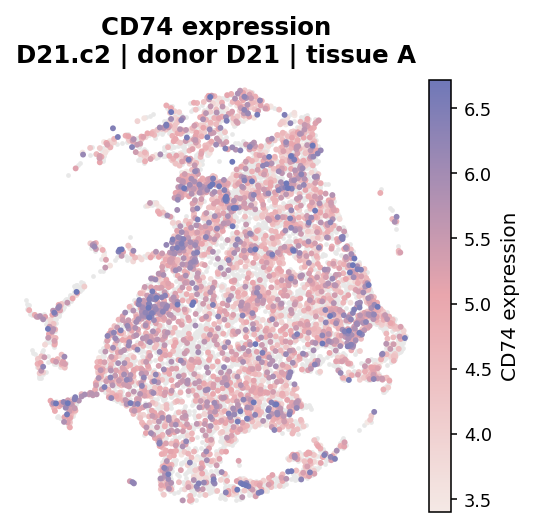

In [52]:
result = plot_gene_spatial_core(
    adata=x_all,
    core_id="D21.c2",
    gene="CD74",
)

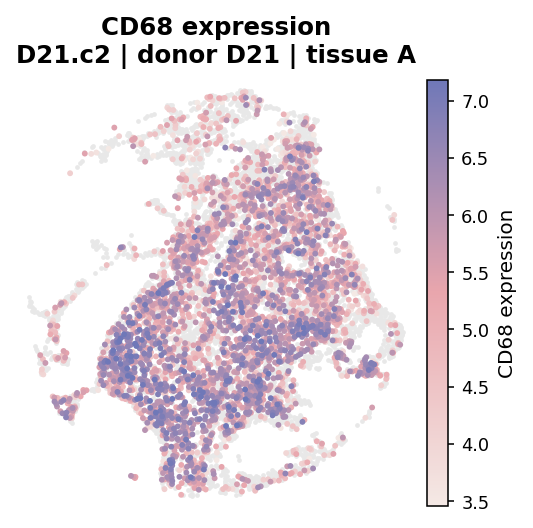

In [53]:
result = plot_gene_spatial_core(
    adata=x_all,
    core_id="D21.c2",
    gene="CD68",
)